In [1]:
import pandas as pd
import numpy as np 

df = pd.read_csv('CTG.csv')

print("Primeras 5 filas del dataset:")
print(df.head())

Primeras 5 filas del dataset:
       FileName        Date      SegFile      b       e    LBE     LB   AC  \
0  Variab10.txt  12/01/1996  CTG0001.txt  240.0   357.0  120.0  120.0  0.0   
1    Fmcs_1.txt  05/03/1996  CTG0002.txt    5.0   632.0  132.0  132.0  4.0   
2    Fmcs_1.txt  05/03/1996  CTG0003.txt  177.0   779.0  133.0  133.0  2.0   
3    Fmcs_1.txt  05/03/1996  CTG0004.txt  411.0  1192.0  134.0  134.0  2.0   
4    Fmcs_1.txt  05/03/1996  CTG0005.txt  533.0  1147.0  132.0  132.0  4.0   

    FM   UC  ...    C    D    E   AD   DE   LD   FS  SUSP  CLASS  NSP  
0  0.0  0.0  ...  0.0  0.0  0.0  0.0  0.0  0.0  1.0   0.0    9.0  2.0  
1  0.0  4.0  ...  0.0  0.0  0.0  1.0  0.0  0.0  0.0   0.0    6.0  1.0  
2  0.0  5.0  ...  0.0  0.0  0.0  1.0  0.0  0.0  0.0   0.0    6.0  1.0  
3  0.0  6.0  ...  0.0  0.0  0.0  1.0  0.0  0.0  0.0   0.0    6.0  1.0  
4  0.0  5.0  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0    2.0  1.0  

[5 rows x 40 columns]


In [2]:
print("\nDimensiones del dataset (filas, columnas):")
print(df.shape)


Dimensiones del dataset (filas, columnas):
(2129, 40)


In [3]:
print("\nInformación general del dataset:")
print(df.info())


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2129 entries, 0 to 2128
Data columns (total 40 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   FileName  2126 non-null   object 
 1   Date      2126 non-null   object 
 2   SegFile   2126 non-null   object 
 3   b         2126 non-null   float64
 4   e         2126 non-null   float64
 5   LBE       2126 non-null   float64
 6   LB        2126 non-null   float64
 7   AC        2126 non-null   float64
 8   FM        2127 non-null   float64
 9   UC        2127 non-null   float64
 10  ASTV      2127 non-null   float64
 11  MSTV      2127 non-null   float64
 12  ALTV      2127 non-null   float64
 13  MLTV      2127 non-null   float64
 14  DL        2128 non-null   float64
 15  DS        2128 non-null   float64
 16  DP        2128 non-null   float64
 17  DR        2128 non-null   float64
 18  Width     2126 non-null   float64
 19  Min       2126 non-null   float64
 

In [4]:
# Eliminamos columnas de metadatos que no sirven para predicción
print("\nEliminando columnas de metadatos...")

cols_drop = ['FileName', 'Date', 'SegFile', 'b', 'e']
df = df.drop(columns=cols_drop, errors='ignore')

print("Columnas eliminadas (si existían):", cols_drop)
print("Columnas restantes en el dataset:")
print(df.columns)


Eliminando columnas de metadatos...
Columnas eliminadas (si existían): ['FileName', 'Date', 'SegFile', 'b', 'e']
Columnas restantes en el dataset:
Index(['LBE', 'LB', 'AC', 'FM', 'UC', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'DL',
       'DS', 'DP', 'DR', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode',
       'Mean', 'Median', 'Variance', 'Tendency', 'A', 'B', 'C', 'D', 'E', 'AD',
       'DE', 'LD', 'FS', 'SUSP', 'CLASS', 'NSP'],
      dtype='object')


In [5]:
df

,LBE,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,120.0,120.0,0.0,0.0,0.0,73.0,0.5,43.0,2.4,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
1,132.0,132.0,4.0,0.0,4.0,17.0,2.1,0.0,10.4,2.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
2,133.0,133.0,2.0,0.0,5.0,16.0,2.1,0.0,13.4,2.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,134.0,134.0,2.0,0.0,6.0,16.0,2.4,0.0,23.0,2.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,132.0,132.0,4.0,0.0,5.0,16.0,2.4,0.0,19.9,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2124,140.0,140.0,1.0,0.0,9.0,78.0,0.4,27.0,7.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0
2125,142.0,142.0,1.0,1.0,5.0,74.0,0.4,36.0,5.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Nulos por columna
print("\nVerificando valores nulos por columna...")

null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

if null_counts.sum() == 0:
    print("No se encontraron valores nulos en el dataset.")
else:
    print("Se encontraron valores nulos. Se evaluará el método de imputación.")


Verificando valores nulos por columna...
LBE         3
LB          3
AC          3
FM          2
UC          2
ASTV        2
MSTV        2
ALTV        2
MLTV        2
DL          1
DS          1
DP          1
DR          1
Width       3
Min         3
Max         3
Nmax        3
Nzeros      3
Mode        3
Mean        3
Median      3
Variance    3
Tendency    3
A           3
B           3
C           3
D           3
E           3
AD          3
DE          3
LD          3
FS          3
SUSP        3
CLASS       3
NSP         3
dtype: int64
Se encontraron valores nulos. Se evaluará el método de imputación.


In [7]:
print("\nEstadísticos descriptivos de las variables numéricas:")
print(df.describe())


Estadísticos descriptivos de las variables numéricas:
               LBE           LB           AC           FM           UC  \
count  2126.000000  2126.000000  2126.000000  2127.000000  2127.000000   
mean    133.303857   133.303857     2.722484     7.503056     3.669017   
std       9.840844     9.840844     3.560850    39.030452     2.877148   
min     106.000000   106.000000     0.000000     0.000000     0.000000   
25%     126.000000   126.000000     0.000000     0.000000     1.000000   
50%     133.000000   133.000000     1.000000     0.000000     3.000000   
75%     140.000000   140.000000     4.000000     2.000000     5.000000   
max     160.000000   160.000000    26.000000   564.000000    23.000000   

              ASTV         MSTV         ALTV         MLTV           DL  ...  \
count  2127.000000  2127.000000  2127.000000  2127.000000  2128.000000  ...   
mean     47.008933     1.335449     9.884814     8.207616     1.576128  ...   
std      17.210648     0.891543    18.476

In [8]:
print("\nInformación general del dataset:")
print(df.info())


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2129 entries, 0 to 2128
Data columns (total 35 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LBE       2126 non-null   float64
 1   LB        2126 non-null   float64
 2   AC        2126 non-null   float64
 3   FM        2127 non-null   float64
 4   UC        2127 non-null   float64
 5   ASTV      2127 non-null   float64
 6   MSTV      2127 non-null   float64
 7   ALTV      2127 non-null   float64
 8   MLTV      2127 non-null   float64
 9   DL        2128 non-null   float64
 10  DS        2128 non-null   float64
 11  DP        2128 non-null   float64
 12  DR        2128 non-null   float64
 13  Width     2126 non-null   float64
 14  Min       2126 non-null   float64
 15  Max       2126 non-null   float64
 16  Nmax      2126 non-null   float64
 17  Nzeros    2126 non-null   float64
 18  Mode      2126 non-null   float64
 19  Mean      2126 non-null   float64
 

In [9]:
print("\nRegistros donde la variable 'NSP' tiene valores nulos:")
print(df[df['NSP'].isnull()])


Registros donde la variable 'NSP' tiene valores nulos:
      LBE  LB  AC     FM    UC  ASTV  MSTV  ALTV  MLTV    DL  ...   C   D   E  \
2126  NaN NaN NaN    NaN   NaN   NaN   NaN   NaN   NaN   NaN  ... NaN NaN NaN   
2127  NaN NaN NaN    NaN   NaN   NaN   NaN   NaN   NaN   0.0  ... NaN NaN NaN   
2128  NaN NaN NaN  564.0  23.0  87.0   7.0  91.0  50.7  16.0  ... NaN NaN NaN   

      AD  DE  LD  FS  SUSP  CLASS  NSP  
2126 NaN NaN NaN NaN   NaN    NaN  NaN  
2127 NaN NaN NaN NaN   NaN    NaN  NaN  
2128 NaN NaN NaN NaN   NaN    NaN  NaN  

[3 rows x 35 columns]


In [10]:
print("\nEliminando registros con valores nulos en la variable objetivo 'NSP'...")

df_clean = df.dropna(subset=['NSP'])

print("Registros antes de la limpieza:", df.shape[0])
print("Registros después de la limpieza:", df_clean.shape[0])


Eliminando registros con valores nulos en la variable objetivo 'NSP'...
Registros antes de la limpieza: 2129
Registros después de la limpieza: 2126


In [11]:
print("\nInformación general del dataset después de la limpieza:")
print(df_clean.info())


Información general del dataset después de la limpieza:
<class 'pandas.core.frame.DataFrame'>
Index: 2126 entries, 0 to 2125
Data columns (total 35 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LBE       2126 non-null   float64
 1   LB        2126 non-null   float64
 2   AC        2126 non-null   float64
 3   FM        2126 non-null   float64
 4   UC        2126 non-null   float64
 5   ASTV      2126 non-null   float64
 6   MSTV      2126 non-null   float64
 7   ALTV      2126 non-null   float64
 8   MLTV      2126 non-null   float64
 9   DL        2126 non-null   float64
 10  DS        2126 non-null   float64
 11  DP        2126 non-null   float64
 12  DR        2126 non-null   float64
 13  Width     2126 non-null   float64
 14  Min       2126 non-null   float64
 15  Max       2126 non-null   float64
 16  Nmax      2126 non-null   float64
 17  Nzeros    2126 non-null   float64
 18  Mode      2126 non-null   float64
 19  Mean      2126 no


Analizando la distribución de la variable objetivo 'NSP'...


C:\Users\OsatoSec\AppData\Local\Temp\ipykernel_3604\746260688.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='NSP', data=df_clean, palette='viridis')


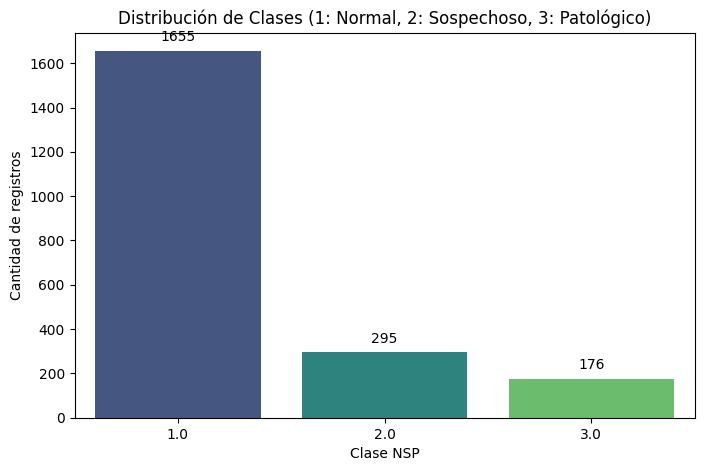


Distribución porcentual de la variable NSP:
NSP
1.0    77.845720
2.0    13.875823
3.0     8.278457
Name: proportion, dtype: float64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nAnalizando la distribución de la variable objetivo 'NSP'...")

plt.figure(figsize=(8, 5))

ax = sns.countplot(x='NSP', data=df_clean, palette='viridis')

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),
        textcoords='offset points'
    )

plt.title('Distribución de Clases (1: Normal, 2: Sospechoso, 3: Patológico)')
plt.xlabel('Clase NSP')
plt.ylabel('Cantidad de registros')
plt.show()

print("\nDistribución porcentual de la variable NSP:")
print(df_clean['NSP'].value_counts(normalize=True) * 100)



Analizando la correlación entre variables morfológicas...
Variables morfológicas utilizadas:
['Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency']


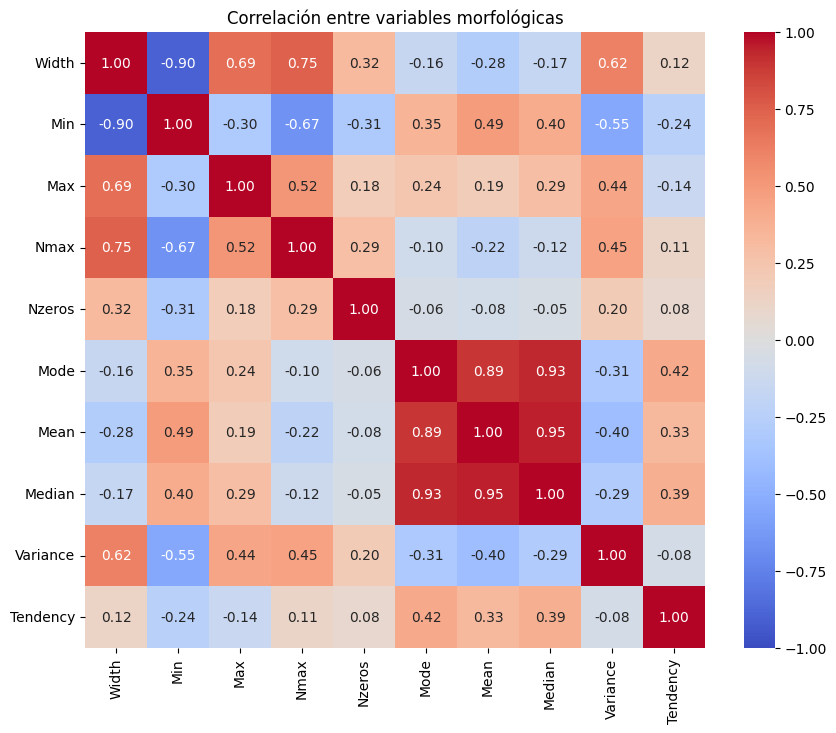

In [13]:
print("\nAnalizando la correlación entre variables morfológicas...")

morph_cols = ['Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode',
              'Mean', 'Median', 'Variance', 'Tendency']

# Verificar que las columnas existan
morph_cols_valid = [col for col in morph_cols if col in df_clean.columns]

print("Variables morfológicas utilizadas:")
print(morph_cols_valid)

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_clean[morph_cols_valid].corr(),
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)
plt.title('Correlación entre variables morfológicas')
plt.show()



Analizando la relación entre Movimientos Fetales (FM) y Aceleraciones (AC)...


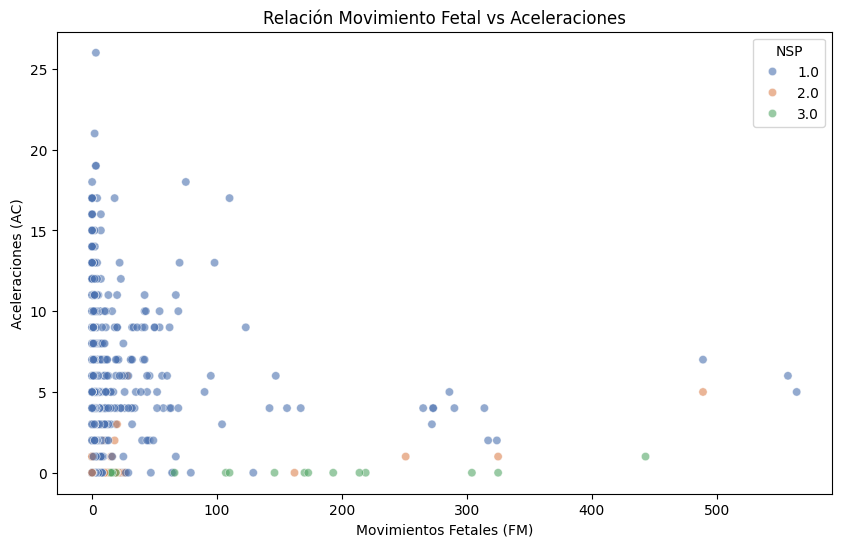

In [14]:
print("\nAnalizando la relación entre Movimientos Fetales (FM) y Aceleraciones (AC)...")

# Verificar que las columnas existan
required_cols = ['FM', 'AC', 'NSP']
missing_cols = [col for col in required_cols if col not in df_clean.columns]

if missing_cols:
    print("Advertencia: faltan las siguientes columnas:", missing_cols)
else:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x='FM',
        y='AC',
        hue='NSP',
        data=df_clean,
        palette='deep',
        alpha=0.6
    )
    plt.title('Relación Movimiento Fetal vs Aceleraciones')
    plt.xlabel('Movimientos Fetales (FM)')
    plt.ylabel('Aceleraciones (AC)')
    plt.show()


In [15]:
from sklearn.ensemble import IsolationForest

print("\nAplicando detección de anomalías con Isolation Forest...")

# Usamos solo variables numéricas
num_cols = df_clean.select_dtypes(include='number').columns
X_anomaly = df_clean[num_cols]

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

df_clean['anomaly'] = iso_forest.fit_predict(X_anomaly)

print("Conteo de registros normales (1) y anomalías (-1):")
print(df_clean['anomaly'].value_counts())



Aplicando detección de anomalías con Isolation Forest...
Conteo de registros normales (1) y anomalías (-1):
anomaly
 1    2019
-1     107
Name: count, dtype: int64


C:\Users\OsatoSec\AppData\Local\Temp\ipykernel_3604\1968161391.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['anomaly'] = iso_forest.fit_predict(X_anomaly)



Visualizando anomalías en espacio PCA...


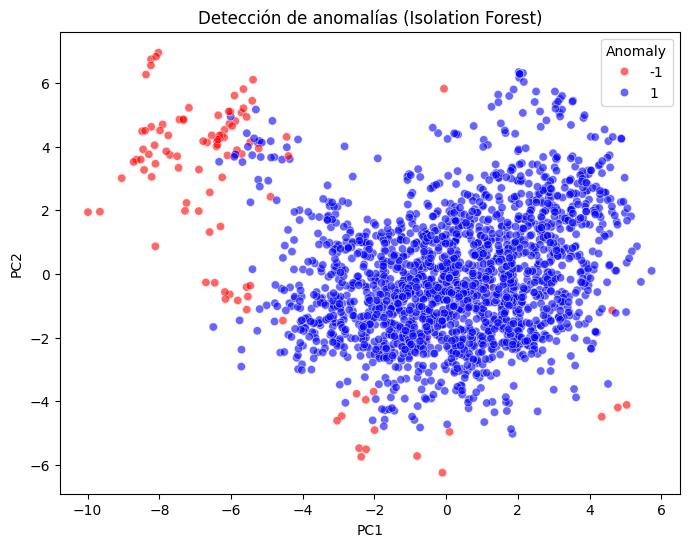

In [17]:
print("\nVisualizando anomalías en espacio PCA...")

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler_anom = StandardScaler()
X_scaled_anom = scaler_anom.fit_transform(X_anomaly)

pca = PCA(n_components=2)
X_pca_anom = pca.fit_transform(X_scaled_anom)

df_pca_anom = pd.DataFrame(X_pca_anom, columns=['PC1', 'PC2'])
df_pca_anom['Anomaly'] = df_clean['anomaly']

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Anomaly',
    data=df_pca_anom,
    palette={1: 'blue', -1: 'red'},
    alpha=0.6
)
plt.title('Detección de anomalías (Isolation Forest)')
plt.show()


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("\nPreparando variables X e y...")

X = df_clean.drop(columns=['NSP', 'CLASS'])
y = df_clean['NSP']

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

print("\nDividiendo dataset en entrenamiento y prueba (80/20) con estratificación...")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Proporción de Patológicos (Clase 3) en Train:", (y_train == 3).mean())
print("Proporción de Patológicos (Clase 3) en Test: ", (y_test == 3).mean())

print("\nEstandarizando variables...")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Estandarización completada.")

print("\nDimensiones finales:")
print(f"Train: {X_train_scaled.shape}")
print(f"Test:  {X_test_scaled.shape}")



Preparando variables X e y...
Dimensiones de X: (2126, 34)
Dimensiones de y: (2126,)

Dividiendo dataset en entrenamiento y prueba (80/20) con estratificación...
Proporción de Patológicos (Clase 3) en Train: 0.08294117647058824
Proporción de Patológicos (Clase 3) en Test:  0.08215962441314555

Estandarizando variables...
Estandarización completada.

Dimensiones finales:
Train: (1700, 34)
Test:  (426, 34)


In [19]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

print("\nEntrenando modelo base SVC (parámetros por defecto)...")

svc_base = SVC(random_state=42)

svc_base.fit(X_train_scaled, y_train)

print("Modelo base entrenado.")

y_pred_base = svc_base.predict(X_test_scaled)

print("\nAccuracy del modelo base SVC:")
print(accuracy_score(y_test, y_pred_base))

print("\nReporte del Modelo Base (SVC Default):")
print(classification_report(y_test, y_pred_base))



Entrenando modelo base SVC (parámetros por defecto)...
Modelo base entrenado.

Accuracy del modelo base SVC:
0.9788732394366197

Reporte del Modelo Base (SVC Default):
              precision    recall  f1-score   support

         1.0       0.98      0.99      0.99       332
         2.0       0.98      0.88      0.93        59
         3.0       0.97      1.00      0.99        35

    accuracy                           0.98       426
   macro avg       0.98      0.96      0.97       426
weighted avg       0.98      0.98      0.98       426



In [20]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import numpy as np

print("\nOptimizando SVC usando RandomizedSearchCV...")

param_dist = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid'],
    'degree': randint(2, 6)
}

random_search = RandomizedSearchCV(
    estimator=SVC(random_state=42, class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

print("Ejecutando RandomizedSearchCV...")
random_search.fit(X_train_scaled, y_train)

print("\nMejores parámetros encontrados:")
print(random_search.best_params_)

print(f"Mejor score en validación (F1 weighted): {random_search.best_score_:.4f}")



Optimizando SVC usando RandomizedSearchCV...
Ejecutando RandomizedSearchCV...

Mejores parámetros encontrados:
{'C': 10, 'degree': 5, 'gamma': 0.01, 'kernel': 'rbf'}
Mejor score en validación (F1 weighted): 0.9911


In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

print("\nOptimizando SVC con GridSearchCV (búsqueda fina)...")

param_grid = {
    'C': [5, 8, 10, 12, 15],
    'gamma': [0.005, 0.008, 0.01, 0.012, 0.02],
    'kernel': ['rbf']
}

grid_search = GridSearchCV(
    estimator=SVC(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("\nMejores parámetros encontrados (GridSearch):")
print(grid_search.best_params_)

print(f"Mejor score en validación (F1 weighted): {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

print("\nEvaluando el modelo optimizado en el conjunto de prueba...")

y_pred_opt = best_model.predict(X_test_scaled)

print("Accuracy modelo optimizado:", accuracy_score(y_test, y_pred_opt))

print("\nREPORTE FINAL DEL MODELO OPTIMIZADO:")
print(classification_report(y_test, y_pred_opt))



Optimizando SVC con GridSearchCV (búsqueda fina)...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Mejores parámetros encontrados (GridSearch):
{'C': 5, 'gamma': 0.02, 'kernel': 'rbf'}
Mejor score en validación (F1 weighted): 0.9923

Evaluando el modelo optimizado en el conjunto de prueba...
Accuracy modelo optimizado: 0.9812206572769953

REPORTE FINAL DEL MODELO OPTIMIZADO:
              precision    recall  f1-score   support

         1.0       0.99      0.99      0.99       332
         2.0       0.96      0.92      0.94        59
         3.0       0.97      1.00      0.99        35

    accuracy                           0.98       426
   macro avg       0.97      0.97      0.97       426
weighted avg       0.98      0.98      0.98       426




Aplicando agrupamiento no supervisado con K-Means...
Agrupamiento K-Means completado.

Aplicando PCA para reducción de dimensionalidad (2 componentes)...
PCA aplicado correctamente.
Varianza explicada por cada componente:
[0.2201999  0.12940663]


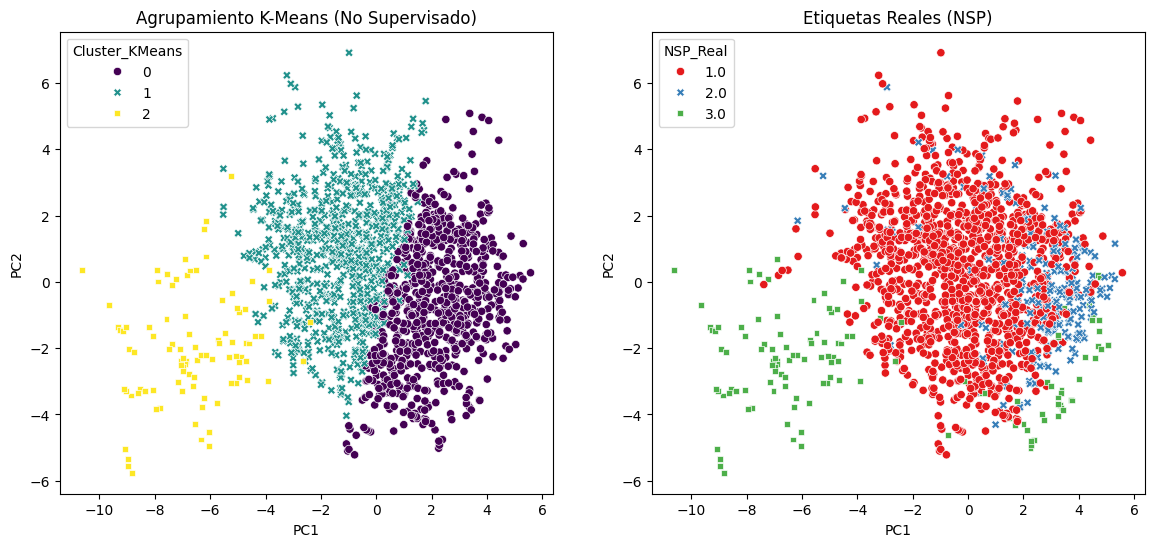


Comparación entre clusters generados y clases reales (NSP):
Cluster K-Means    0    1   2
Realidad                     
1.0              516  801   6
2.0              214   20   2
3.0               53    1  87


In [22]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

print("\nAplicando agrupamiento no supervisado con K-Means...")

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_scaled)

print("Agrupamiento K-Means completado.")

print("\nAplicando PCA para reducción de dimensionalidad (2 componentes)...")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

print("PCA aplicado correctamente.")
print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster_KMeans'] = clusters
df_pca['NSP_Real'] = y_train.values

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster_KMeans',
    data=df_pca,
    palette='viridis',
    style='Cluster_KMeans'
)
plt.title('Agrupamiento K-Means (No Supervisado)')

plt.subplot(1, 2, 2)
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='NSP_Real',
    data=df_pca,
    palette='Set1',
    style='NSP_Real'
)
plt.title('Etiquetas Reales (NSP)')

plt.show()

print("\nComparación entre clusters generados y clases reales (NSP):")
print(pd.crosstab(
    df_pca['NSP_Real'],
    df_pca['Cluster_KMeans'],
    rownames=['Realidad'],
    colnames=['Cluster K-Means']
))
